# Define surface layer and pycnocline layer

Following [Randelhoff et al. 2017](https://journals.ametsoc.org/view/journals/phoc/47/4/jpo-d-16-0200.1.xml#fig2)

Defining three layers:
1. Surface layer
2. Pycnocline
3. Deep water column

Defined depending on their upper density relative to a deep reference density. 
- Upper density ($\sigma_{\theta 0}$) is the average potential density over 3-5 m.
- Deep density ($\sigma_{\theta d}$) is defined in a depth range where density stratification stabilizes - for their study area it is around 50m and they take the average between 45-50m. Deep density is determined ad hoc but we need to check to make sure results are not sensitive to the depth range selected.

We then create a scaled depth coordinate between 0 and 1 (values exceeding this interval are set to 0 or 1, respectively): 

$r_{\sigma}(z) =$ [$\sigma_\theta(z) - \sigma_{\theta0}$]/$\Delta\sigma_{\theta}$ 

where $\Delta\sigma_{\theta}$ = $\sigma_{\theta d} - \sigma_{\theta 0}$ representing the surface density deviation (i.e., deep minus upper layer)

The surface layer (SL) is where 0 $\leq r_{\sigma} <$ 0.2 <br>
The pycnocline layer (PC) is where 0.2 $\leq r_{\sigma} \leq$ 0.8 <br>
Deep water column (DW) is where $r_{\sigma} >$ 0.8 <br>

*The top and bottom of the PC are defined by the depths where the water density reaches 20% and 80% of the total density difference between the surface and deep water.*

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:46195")
client

<Client: 'tcp://127.0.0.1:46195' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [6]:
# open SALT zarr store - [psu]
SALT_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options)

# open THETA zarr store - [degC]
THETA_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options)

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
SI_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options)

# open RHOAnoma zarr store - [fraction of sea ice, 0 to 1]
RHOAnoma_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/RHOAnoma_AVG_DAILY.ZARR/', s3_options)

In [7]:
# remove 2021 since we only have January and a few days in Feb that year
salt_day = SALT_zarr_day.SALT.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
theta_day = THETA_zarr_day.THETA.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
ice_day = SI_zarr_day.SIarea.sel(time=slice("2014","2020")).where(HH_grid.mask_basin.isel(k=0)==1)*100 # convert to percentage

# add reference density to density anomaly (RHOAnoma)
rhoConst = 1027.5 # reference density
density_day = RHOAnoma_zarr_day.RHOAnoma.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1) + rhoConst - 1000 # minus 1000 to get potential density

In [8]:
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)

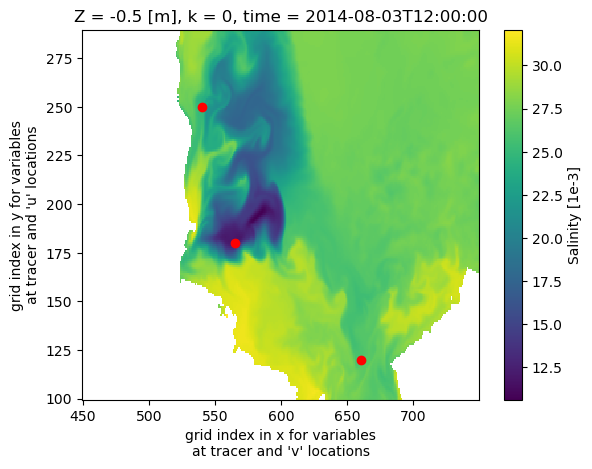

In [9]:
# plot Beaufort Sea area
salt_day.isel(k=0,i=slice(450,750),j=slice(100,290),time=200).plot();
plt.scatter(565,180,c='r');
plt.scatter(540,250,c='r');
plt.scatter(660,120,c='r');

In [38]:
grid_volume = HH_grid.rAc*HH_grid.drF*HH_grid.hFacC

In [39]:
i=565
j=180
date = "2019-12-15"

In [60]:
rho = density_day.sel(time=date).isel(i=i, j=j,time=0)
vol = grid_volume.isel(i=i, j=j)

In [61]:
# UPPER
# calculate surface density by taking volume-weighted average of upper 5 grid cells from 0.5 to 5.78 m
rho_upper = rho.isel(k=slice(0,5))
vol_upper = vol.isel(k=slice(0,5))

# rho_avg_upper = (rho_upper*vol_upper).sum(dim=('k','i','j')).compute()/vol_upper.sum()
rho_avg_upper = (rho_upper*vol_upper).sum(dim=('k')).compute()/vol_upper.sum()

In [63]:
# DEEP
# calculate deep density by taking volume-weighted average of 3 grid cells from ~39 to 52
rho_deep = rho.isel(k=slice(14,17))
vol_deep = vol.isel(k=slice(14,17))
rho_avg_deep = (rho_deep*vol_deep).sum(dim=('k')).compute()/vol_deep.sum()

In [64]:
# calculate the surface density deviation
delta_rho = rho_avg_deep - rho_avg_upper

In [65]:
# create a scaled depth coordinate between 0 and 1 
scaled_dens_coord = (rho - rho_avg_upper) / delta_rho

In [ ]:
# this would replace values less than 0 to equal 0 and values over 1 to equal 1
# we don't really need this though because we will just pull all values above and below those limits
# scaled_dens_coord.clip(min=0, max=1).values

In [72]:
SL_mask = scaled_dens_coord < 0.2
PC_mask = (scaled_dens_coord >= 0.2) & (scaled_dens_coord <= 0.8)
DW_mask = scaled_dens_coord > 0.8

In [77]:
(HH_grid.Z*SL_mask).values

array([-0.5  , -1.57 , -2.79 , -4.185, -5.78 , -7.595, -0.   , -0.   ,
       -0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   ,
       -0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   ,
       -0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   ,
       -0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   ,
       -0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   ,
       -0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   ,
       -0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   ,
       -0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   ,
       -0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   ,
       -0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   ,
       -0.   , -0.   ], dtype=float32)

In [82]:
SL_bottom_depth = HH_grid.Z.where(SL_mask.compute(), drop=True).min().values
DW_upper_depth = HH_grid.Z.where(DW_mask.compute(), drop=True).max().values

In [84]:
SL_bottom_depth

array(-7.595, dtype=float32)

In [83]:
DW_upper_depth

array(-17.705, dtype=float32)

In [154]:
def plot_profile(date, theta_day, salt_day, density_day, HH_grid, i=565, j=180):
    """
    Plots temperature and salinity profiles for a single date with solid lines,
    with salinity as a secondary axis on the temperature plot, and density on a separate axis.

    Parameters:
    - date: Date to plot (must be a string in 'YYYY-MM-DD' format).
    - theta_day: Dataset containing temperature values.
    - salt_day: Dataset containing salinity values.
    - density_day: Dataset containing density values.
    - HH_grid: Grid object containing `rAc`, `drF`, and `hFacC` for volume calculations.
    - i, j: Grid indices to extract data from (default: 565, 180).
    """
    
    # Create figure and subplots
    plt.rcParams['font.size'] = 16
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[6, 6], sharey=True)

    # Extract data for the given date
    theta = theta_day.sel(time=date).isel(i=i, j=j, time=0)
    salt = salt_day.sel(time=date).isel(i=i, j=j, time=0)
    density = density_day.sel(time=date).isel(i=i, j=j, time=0)
    
    # Calculate grid volume
    grid_volume = HH_grid.rAc * HH_grid.drF * HH_grid.hFacC
    rho = density_day.sel(time=date).isel(i=i, j=j, time=0)
    vol = grid_volume.isel(i=i, j=j)

    # UPPER - Calculate surface density (upper 5 grid cells)
    rho_upper = rho.isel(k=slice(0,5))
    vol_upper = vol.isel(k=slice(0,5))
    rho_avg_upper = (rho_upper * vol_upper).sum(dim=('k')).compute() / vol_upper.sum()

    # DEEP - Calculate deep density (3 grid cells from ~39 to 52)
    rho_deep = rho.isel(k=slice(14,17))
    vol_deep = vol.isel(k=slice(14,17))
    rho_avg_deep = (rho_deep * vol_deep).sum(dim=('k')).compute() / vol_deep.sum()

    # Calculate surface density deviation
    delta_rho = rho_avg_deep - rho_avg_upper

    # Create a scaled depth coordinate between 0 and 1
    scaled_dens_coord = (rho - rho_avg_upper) / delta_rho
    
    SL_mask = scaled_dens_coord < 0.2
    PC_mask = (scaled_dens_coord >= 0.2) & (scaled_dens_coord <= 0.8)
    DW_mask = scaled_dens_coord > 0.8

    SL_bottom_depth = HH_grid.Z.where(SL_mask.compute(), drop=True).min().values
    DW_upper_depth = HH_grid.Z.where(DW_mask.compute(), drop=True).max().values

    # Plot temperature profile
    theta.plot(ax=ax1, y='Z', color='tab:blue', marker='.', linestyle='solid')
    ax1.tick_params(axis='x', colors='tab:blue')

    # Add salinity profile as a secondary axis
    ax1_sec = ax1.twiny()
    salt.plot(ax=ax1_sec, y='Z', color='tab:red', marker='.', linestyle='solid')
    ax1_sec.tick_params(axis='x', colors='tab:red')
    
    # Plot density profile
    density.plot(ax=ax2, y='Z', color='black', marker='.', linestyle='solid')
    ax2.axhline(y=SL_bottom_depth,color='tab:orange',linewidth=1.5,label="Bottom of\nsurface layer")
    ax2.axhline(y=DW_upper_depth,color='tab:orange',linewidth=1.5,linestyle='dashed',label="Bottom of\npycnocline")
    ax2.legend(fontsize=10)
    
    # Formatting axes
    for ax in (ax1, ax1_sec, ax2):
        ax.set_ylim(-60, 3)
        ax.axhline(y=0, c='k', linewidth=0.5, linestyle='dashed')
        ax.set_title("")
    
    # Add labels
    ax1.set_xlabel("Temp ($\degree$C)", color='tab:blue')
    ax1_sec.set_xlabel("Salinity (g/kg)", color='tab:red')
    ax1.set_ylabel("Depth (m)")
    ax2.set_ylabel("")
    ax2.set_xlabel("Density (kg/m³)")
    
    # Add legend
    # ax1.legend(loc='lower left')

    # Add a title to the whole figure
    fig.suptitle(f"Grid cell [i={i}, j={j}]\n{date}", fontsize=14, y=1.05)
    
    # Show the plot
    plt.show()

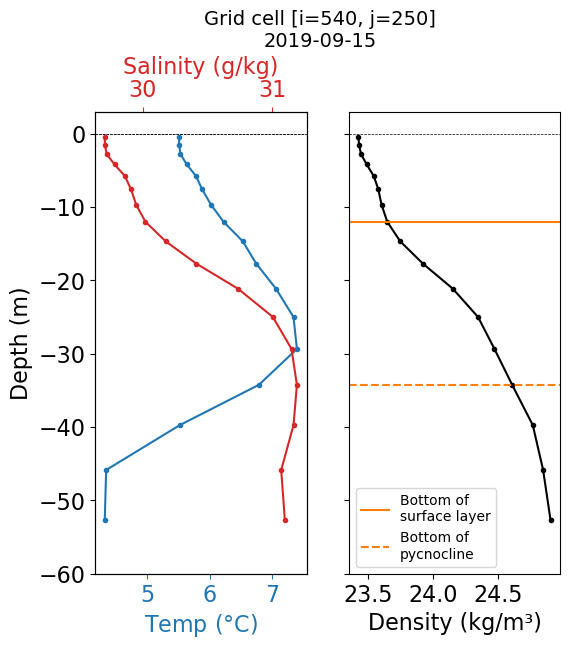

In [155]:
plot_profile("2019-09-15", theta_day, salt_day, density_day, HH_grid, i=540, j=250)

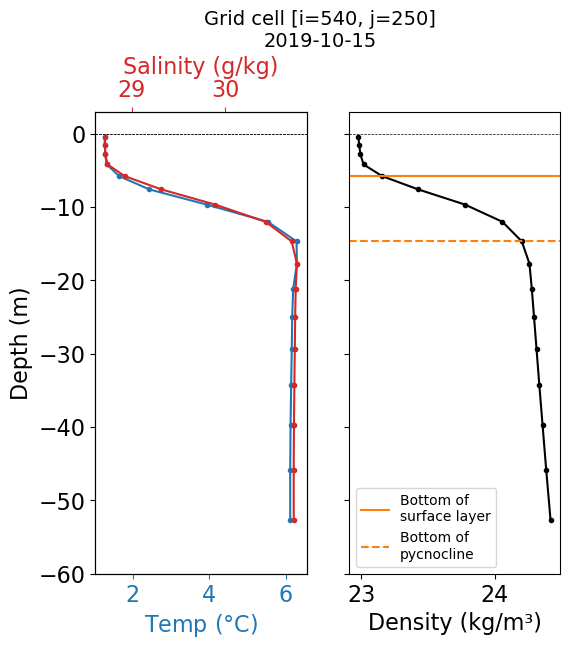

In [156]:
plot_profile("2019-10-15", theta_day, salt_day, density_day, HH_grid, i=540, j=250)

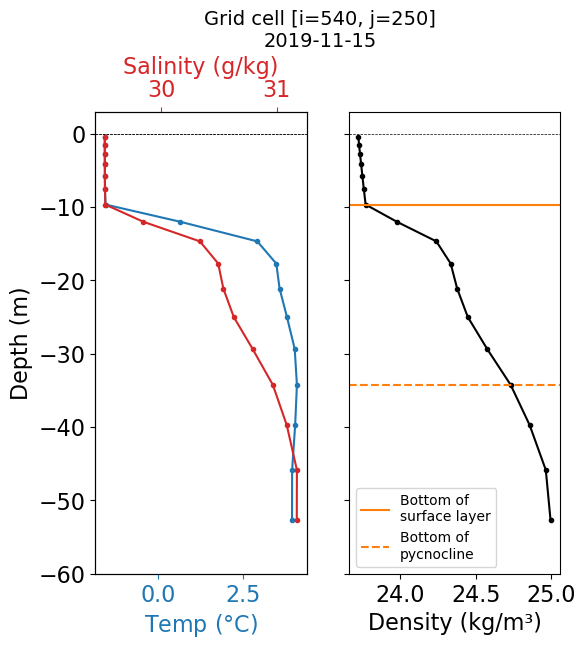

In [157]:
plot_profile("2019-11-15", theta_day, salt_day, density_day, HH_grid, i=540, j=250)

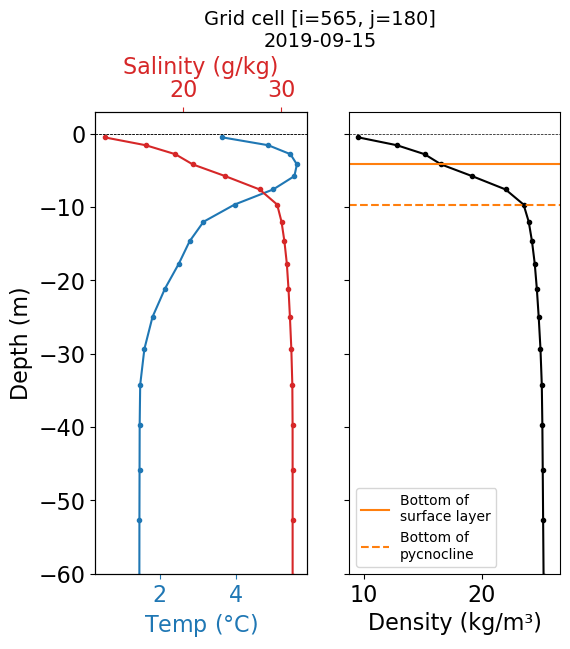

In [158]:
plot_profile("2019-09-15", theta_day, salt_day, density_day, HH_grid, i=565, j=180)

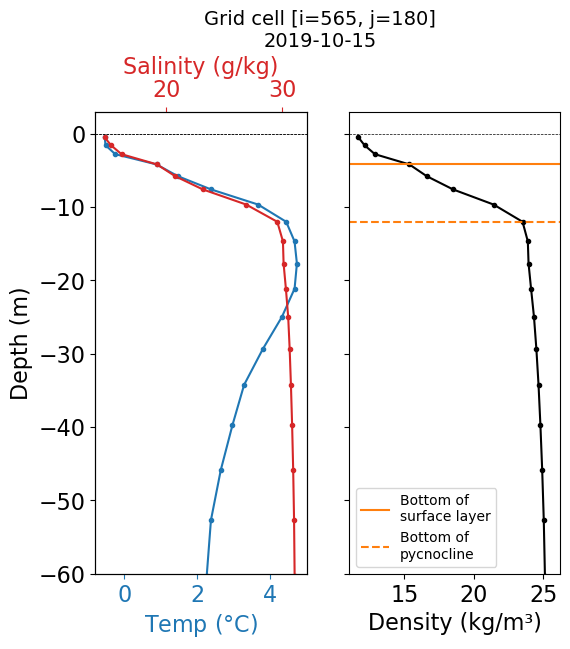

In [159]:
plot_profile("2019-10-15", theta_day, salt_day, density_day, HH_grid, i=565, j=180)

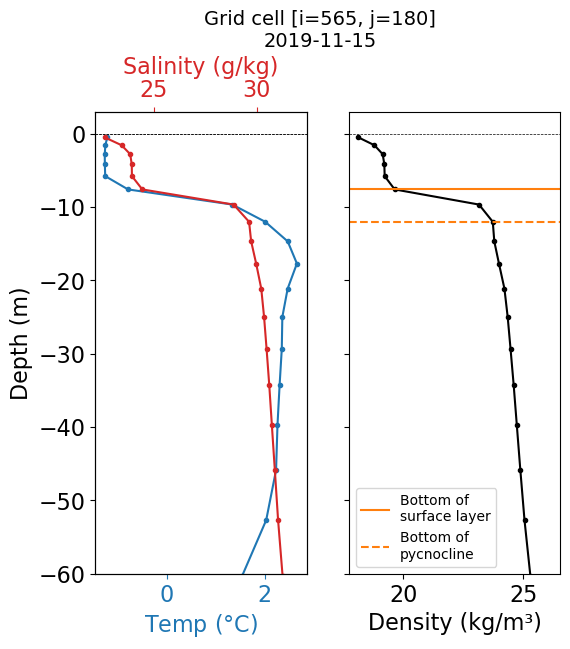

In [160]:
plot_profile("2019-11-15", theta_day, salt_day, density_day, HH_grid, i=565, j=180)

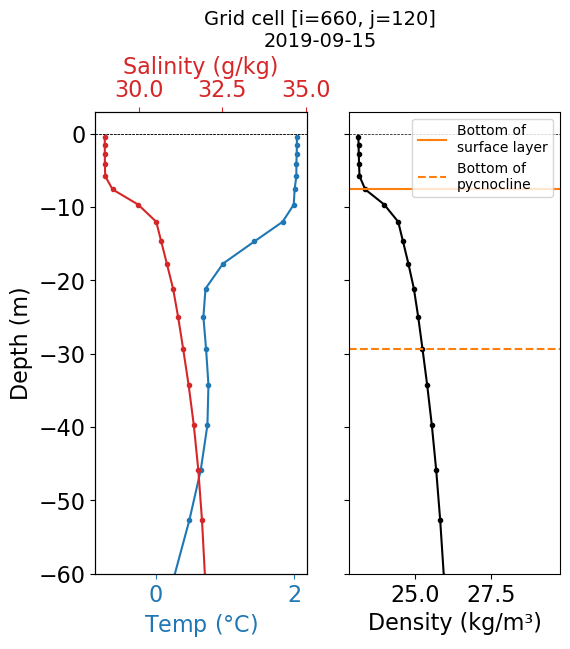

In [161]:
plot_profile("2019-09-15", theta_day, salt_day, density_day, HH_grid, i=660, j=120)

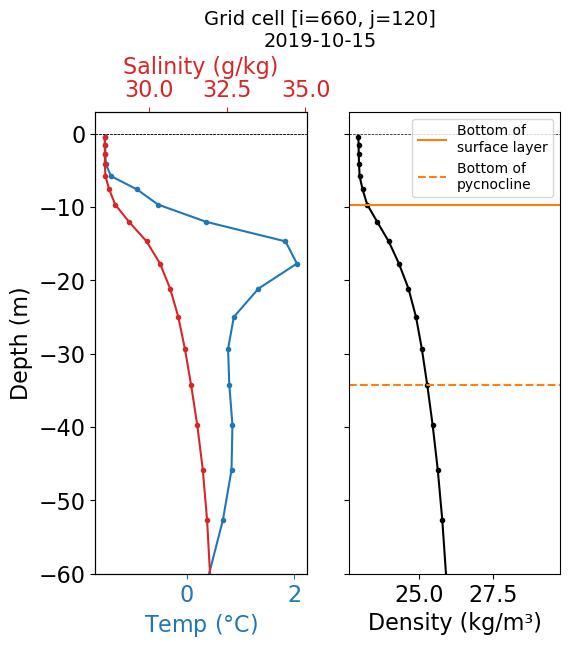

In [162]:
plot_profile("2019-10-15", theta_day, salt_day, density_day, HH_grid, i=660, j=120)

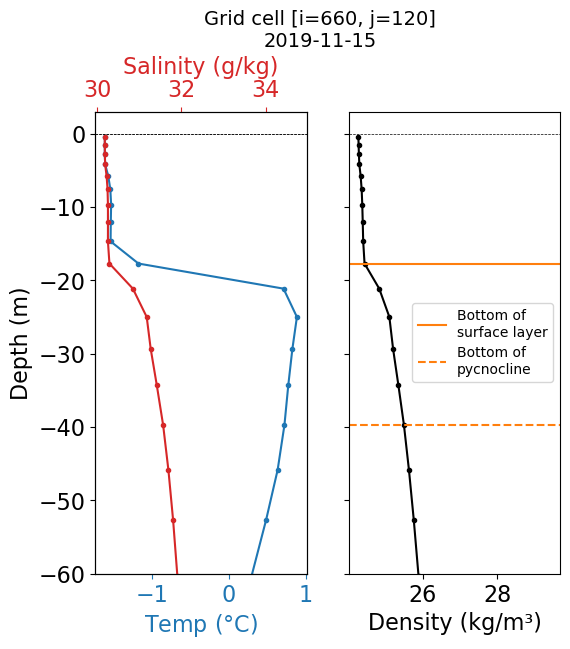

In [163]:
plot_profile("2019-11-15", theta_day, salt_day, density_day, HH_grid, i=660, j=120)

### Include the MLD calculation using a 0.1 kg m^-3 threshold

In [20]:
def plot_profile(date, theta_day, salt_day, density_day, HH_grid, i=565, j=180):
    """
    Plots temperature, salinity, and density profiles for a single date with key density layer markers.
    
    Parameters:
    - date: Date to plot (must be a string in 'YYYY-MM-DD' format).
    - theta_day: Dataset containing temperature values.
    - salt_day: Dataset containing salinity values.
    - density_day: Dataset containing density values.
    - HH_grid: Grid object containing `rAc`, `drF`, and `hFacC` for volume calculations.
    - i, j: Grid indices to extract data from (default: 565, 180).
    """
    # Create figure and subplots
    plt.rcParams['font.size'] = 14
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[6, 6], sharey=True)
    
    # Extract data for the given date
    theta = theta_day.sel(time=date).isel(i=i, j=j, time=0)
    salt = salt_day.sel(time=date).isel(i=i, j=j, time=0)
    density = density_day.sel(time=date).isel(i=i, j=j, time=0)
    
    # Compute MLD
    density_select = density_day.isel(i=i, j=j).sel(time=date)
    rho_surf = density_select.isel(k=0)  # Near-surface density
    density_threshold = 0.1  # kg m^-3
    threshold = rho_surf + density_threshold
    density_minus_threshold = abs(density_select - threshold)
    threshold_idx = density_minus_threshold.argmin(dim='k', skipna=True)
    MLD = density_select.isel(k=threshold_idx.compute()).Z.values.item()
    
    # Calculate grid volume
    grid_volume = HH_grid.rAc * HH_grid.drF * HH_grid.hFacC
    rho = density_day.sel(time=date).isel(i=i, j=j, time=0)
    vol = grid_volume.isel(i=i, j=j)
    
    # UPPER - Calculate surface density (upper 5 grid cells)
    rho_upper = rho.isel(k=slice(0,5))
    vol_upper = vol.isel(k=slice(0,5))
    rho_avg_upper = (rho_upper * vol_upper).sum(dim=('k')).compute() / vol_upper.sum()
    
    # DEEP - Calculate deep density (3 grid cells from ~39 to 52)
    rho_deep = rho.isel(k=slice(14,17))
    vol_deep = vol.isel(k=slice(14,17))
    rho_avg_deep = (rho_deep * vol_deep).sum(dim=('k')).compute() / vol_deep.sum()
    
    # Calculate surface density deviation
    delta_rho = rho_avg_deep - rho_avg_upper
    
    # Create a scaled depth coordinate between 0 and 1
    scaled_dens_coord = (rho - rho_avg_upper) / delta_rho
    
    SL_mask = scaled_dens_coord < 0.2
    PC_mask = (scaled_dens_coord >= 0.2) & (scaled_dens_coord <= 0.8)
    DW_mask = scaled_dens_coord > 0.8
    
    SL_bottom_depth = HH_grid.Z.where(SL_mask.compute(), drop=True).min().values
    DW_upper_depth = HH_grid.Z.where(DW_mask.compute(), drop=True).max().values
    
    # Plot temperature profile
    theta.plot(ax=ax1, y='Z', color='tab:blue', marker='.', linestyle='solid')
    ax1.axhline(y=MLD, linewidth=2, color='tab:green', linestyle='solid', label="MLD")
    ax1.tick_params(axis='x', colors='tab:blue')
    ax1.legend(fontsize=11,loc='lower left')
    
    # Add salinity profile as a secondary axis
    ax1_sec = ax1.twiny()
    salt.plot(ax=ax1_sec, y='Z', color='tab:red', marker='.', linestyle='solid')
    ax1_sec.tick_params(axis='x', colors='tab:red')
    
    # Plot density profile
    density.plot(ax=ax2, y='Z', color='black', marker='.', linestyle='solid')
    ax2.axhline(y=SL_bottom_depth, color='tab:orange', linewidth=1.5, label="Bottom of\nsurface layer")
    ax2.axhline(y=DW_upper_depth, color='tab:orange', linewidth=1.5, linestyle='dashed', label="Bottom of\npycnocline")
    ax2.legend(fontsize=11,loc='lower left')
    
    # Formatting axes
    for ax in (ax1, ax1_sec, ax2):
        # ax.set_ylim(-60, 3)
        ax.axhline(y=0, c='k', linewidth=0.5, linestyle='dashed')
        ax.set_title("")
    
    # Add labels
    ax1.set_xlabel("Temp ($\degree$C)", color='tab:blue')
    ax1_sec.set_xlabel("Salinity (g/kg)", color='tab:red')
    ax1.set_ylabel("Depth (m)")
    ax2.set_ylabel("")
    ax2.set_xlabel("Density (kg/m³)")
    
    # Add title
    fig.suptitle(f"Grid cell [i={i}, j={j}]\n{date}", fontsize=14, y=1.05)
    
    # Show plot
    plt.show()

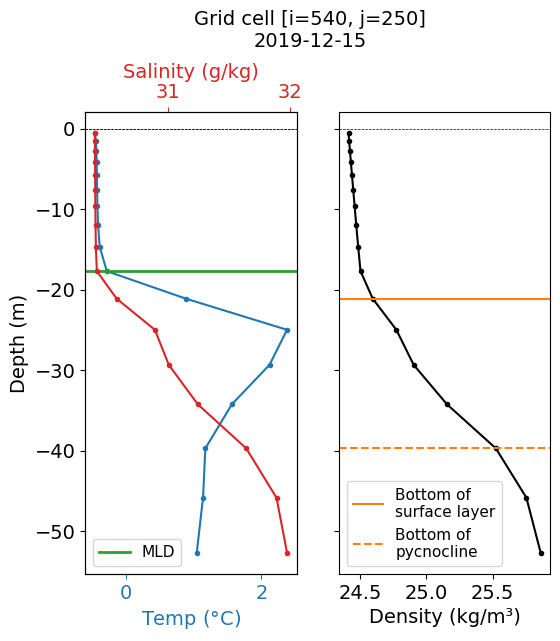

In [27]:
plot_profile("2019-12-15", theta_day, salt_day, density_day, HH_grid, i=540, j=250)

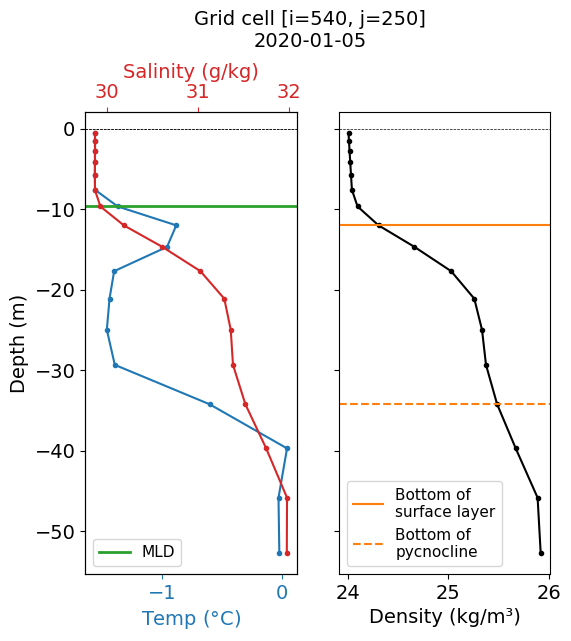

In [30]:
plot_profile("2020-01-05", theta_day, salt_day, density_day, HH_grid, i=540, j=250)

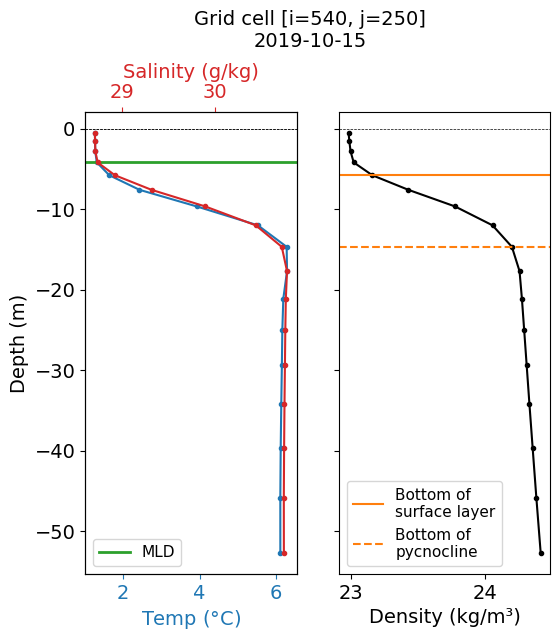

In [25]:
plot_profile("2019-10-15", theta_day, salt_day, density_day, HH_grid, i=540, j=250)

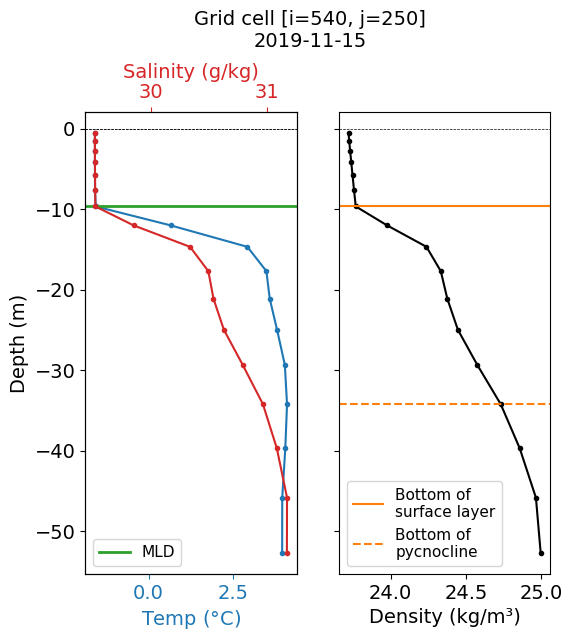

In [26]:
plot_profile("2019-11-15", theta_day, salt_day, density_day, HH_grid, i=540, j=250)

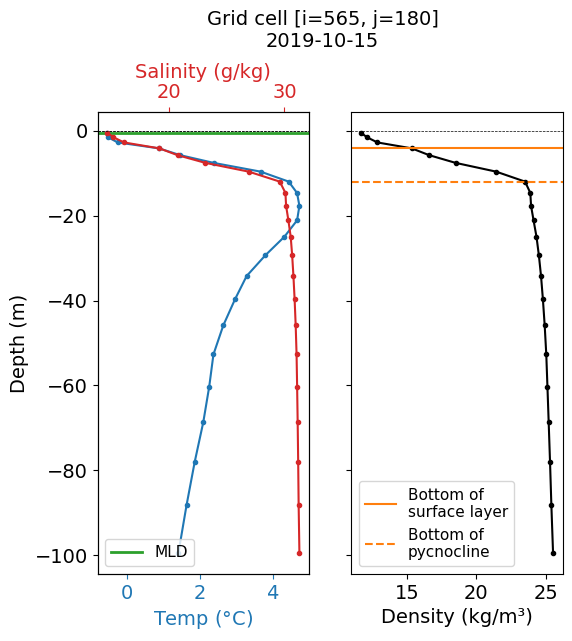

In [22]:
plot_profile("2019-10-15", theta_day, salt_day, density_day, HH_grid, i=565, j=180)

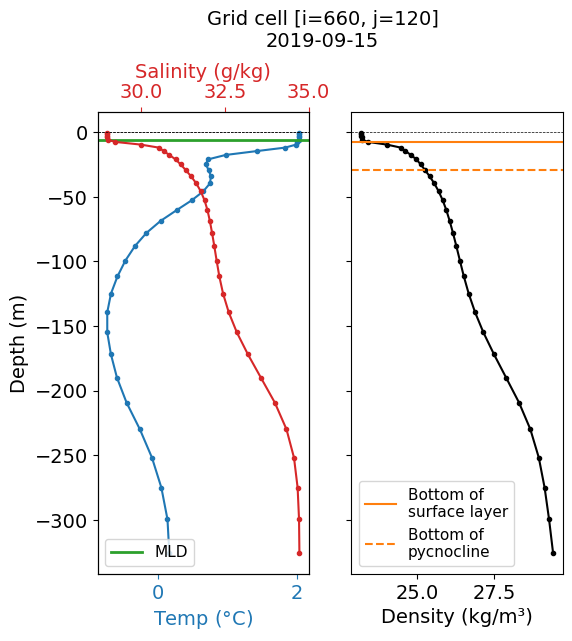

In [31]:
plot_profile("2019-09-15", theta_day, salt_day, density_day, HH_grid, i=660, j=120)

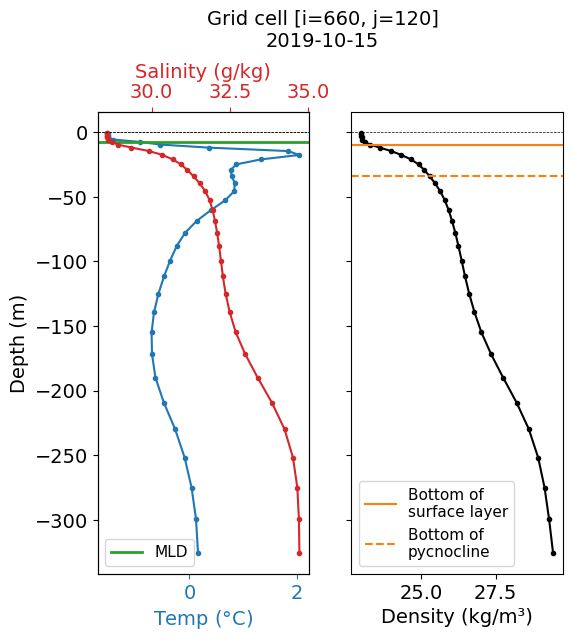

In [32]:
plot_profile("2019-10-15", theta_day, salt_day, density_day, HH_grid, i=660, j=120)

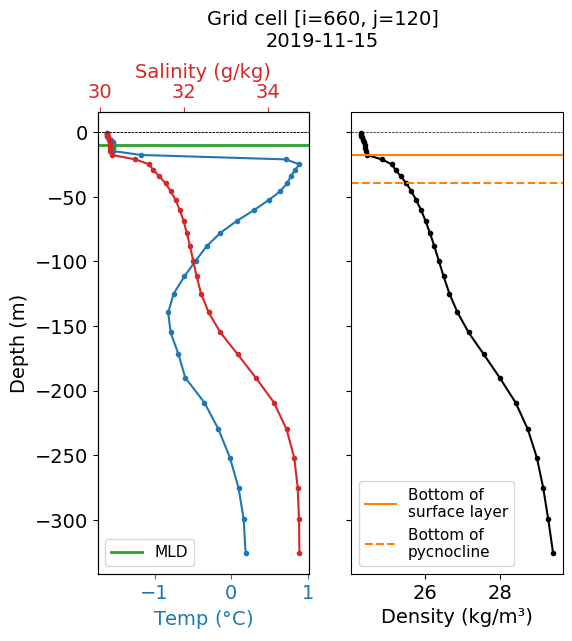

In [33]:
plot_profile("2019-11-15", theta_day, salt_day, density_day, HH_grid, i=660, j=120)